In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX
import optuna


import warnings
warnings.filterwarnings('ignore')

c:\Users\Marwa\anaconda3\envs\cc_abs\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Show all rows
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_rows', 1000)

- DRCC =  Credit Card Delinquency rate (all commercial banks)
- COR = Credit card charge-off rate
- TERM = Terms on Credit Card plans

In [4]:
corc_df = pd.read_csv('../data/CORCCACBS.csv')
drcc_df = pd.read_csv('../data/DRCCLACBS.csv')
term_df = pd.read_csv('../data/TERMCBCCALLNS.csv')

In [5]:
print(corc_df.head(15))
print(drcc_df[drcc_df['date']>'1994'])
print(term_df.head(15))

    Unnamed: 0       realtime_start                 date  value
0            0  2011-05-24 00:00:00  1985-01-01 00:00:00   1.99
1            1  2013-11-15 00:00:00  1985-01-01 00:00:00   1.98
2            2  2015-11-18 00:00:00  1985-01-01 00:00:00   1.99
3            3  2017-02-21 00:00:00  1985-01-01 00:00:00   1.90
4            4  2021-11-22 00:00:00  1985-01-01 00:00:00   1.95
5            5  2022-11-23 00:00:00  1985-01-01 00:00:00   1.90
6            6  2011-05-24 00:00:00  1985-04-01 00:00:00   2.39
7            7  2013-11-15 00:00:00  1985-04-01 00:00:00   2.40
8            8  2017-02-21 00:00:00  1985-04-01 00:00:00   2.26
9            9  2021-11-22 00:00:00  1985-04-01 00:00:00   2.25
10          10  2022-11-23 00:00:00  1985-04-01 00:00:00   2.26
11          11  2011-05-24 00:00:00  1985-07-01 00:00:00   2.73
12          12  2013-11-15 00:00:00  1985-07-01 00:00:00   2.72
13          13  2016-05-18 00:00:00  1985-07-01 00:00:00   2.71
14          14  2017-02-21 00:00:00  198

Organize our data - it currently has multiple entries for each date + has a hours/minutes/second. I'll make a function to make this more streamlined

In [6]:

def fix_df(df):

    a=df.groupby(df['date'])['value'].mean().round(2)
    
    b = pd.to_datetime(df['date'].unique())

    df = pd.DataFrame({
        'date':b,
        'value':a.values
    })

    df = df.set_index('date')

    return df



In [7]:
drcc_df = fix_df(drcc_df)
corc_df = fix_df(corc_df)
term_df = fix_df(term_df)
term_df = term_df.dropna()

In [8]:
print(drcc_df.head(1))
print(corc_df.head(1))
print(term_df.head(1))
print(len(drcc_df),len(corc_df),len(term_df))

            value
date             
1991-01-01   5.27
            value
date             
1985-01-01   1.95
            value
date             
1994-11-01  15.69
140 164 126


Plotting them out 
- They all start at different dates, so I'll start them all at 1995 to have an equal starting date for easier comparison

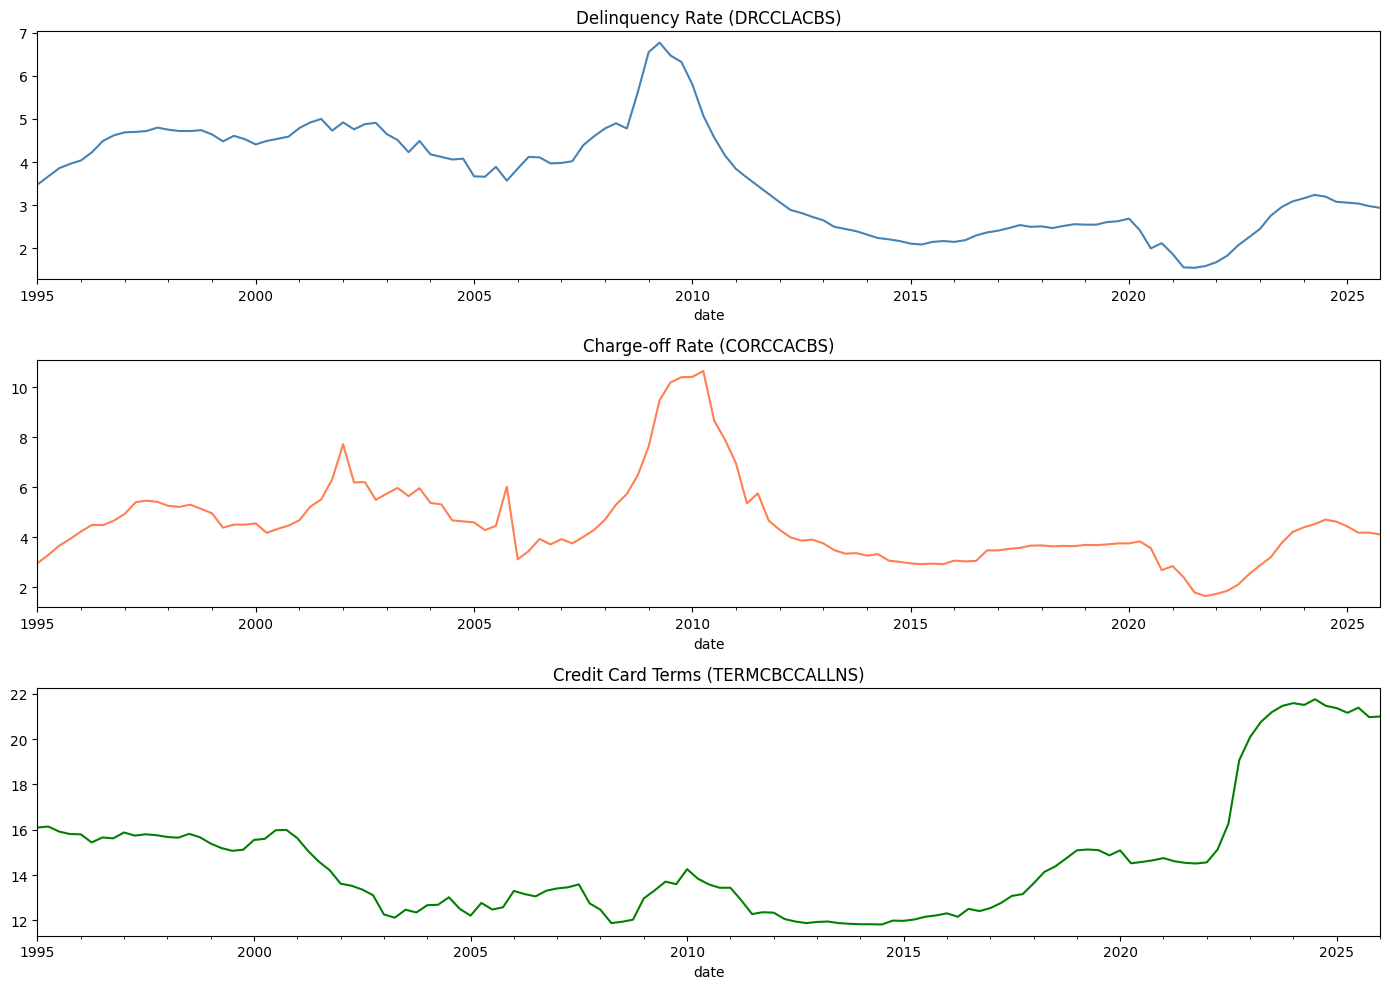

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

drcc_df.loc['1995':]['value'].plot(ax=axes[0], title='Delinquency Rate (DRCCLACBS)', color='steelblue')
corc_df.loc['1995':]['value'].plot(ax=axes[1], title='Charge-off Rate (CORCCACBS)', color='coral')
term_df.loc['1995':]['value'].plot(ax=axes[2], title='Credit Card Terms (TERMCBCCALLNS)', color='green')

plt.tight_layout()
plt.show()

Differenced variables:

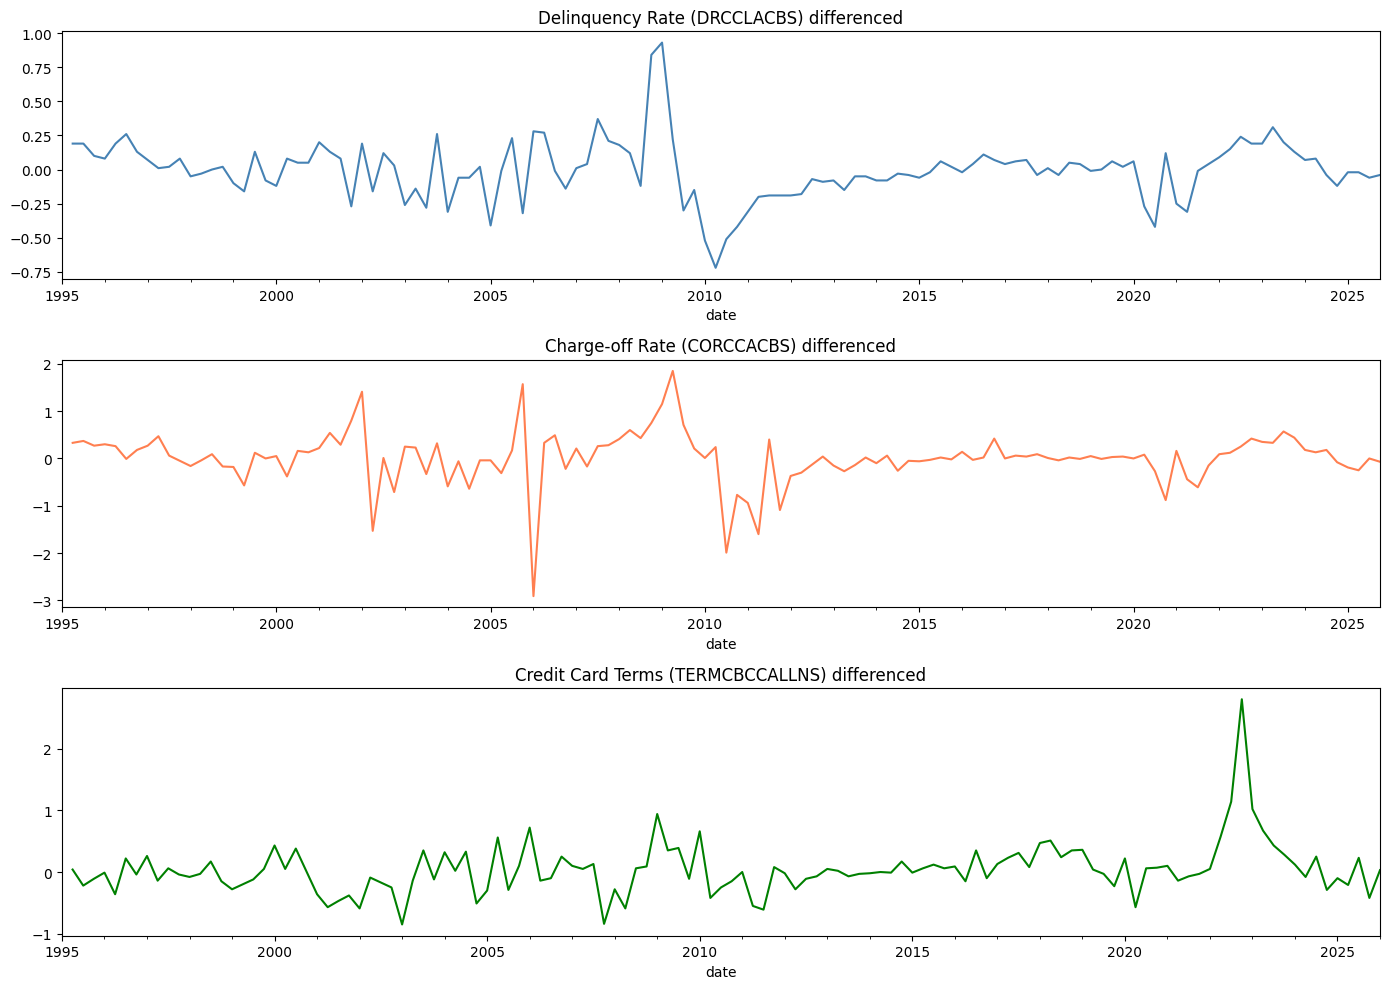

In [10]:
drcc_df_t = drcc_df.loc['1995':]['value'].diff(1)
corc_df_t= corc_df.loc['1995':]['value'].diff(1)
term_df_t= term_df.loc['1995':]['value'].diff(1)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)



drcc_df_t.plot(ax=axes[0], title='Delinquency Rate (DRCCLACBS) differenced', color='steelblue')
corc_df_t.plot(ax=axes[1], title='Charge-off Rate (CORCCACBS) differenced', color='coral')
term_df_t.plot(ax=axes[2], title='Credit Card Terms (TERMCBCCALLNS) differenced', color='green')

plt.tight_layout()
plt.show()

## Stationary Tests ADF / KPSS

In [11]:
#these are the differenced data  - only difference is that we dropped NA in these variables 
drcc_df_t = drcc_df.loc['1995':]['value'].diff(1).dropna()
corc_df_t= corc_df.loc['1995':]['value'].diff(1).dropna()
term_df_t= term_df.loc['1995':]['value'].diff(1).dropna()


dataframes = {'drcc':drcc_df_t,
              'corc':corc_df_t,
              'term':term_df_t}


for name,df in dataframes.items():
    adf_p = adfuller(df)
    print(f'ADF pvalue of {name}: {adf_p[1]}')



    kpss_p = kpss(df,regression='ct')
    print(f'KPSS pvalue of {name}: {kpss_p[1]}')


    if (adf_p[1] < 0.05) & (kpss_p[1] < 0.05): 
        print(f'{name} is ambigious')

    elif (adf_p[1] < 0.05) & (kpss_p[1] > 0.05):
        print(f'{name} is stationary, awwww yeahhhh')

    elif (adf_p[1] > 0.05) & (kpss_p[1] < 0.05):
        print(f'{name} is non-stationary')

    else:
        print(f'{name} is trend stationary')

    print('\n')

ADF pvalue of drcc: 1.4276817589259722e-08
KPSS pvalue of drcc: 0.1
drcc is stationary, awwww yeahhhh


ADF pvalue of corc: 0.0012026433261576699
KPSS pvalue of corc: 0.1
corc is stationary, awwww yeahhhh


ADF pvalue of term: 7.266715677590607e-05
KPSS pvalue of term: 0.1
term is stationary, awwww yeahhhh




ACF / PACF Plots - of charge off rates and Term. Delinquency plot's in notebook 1

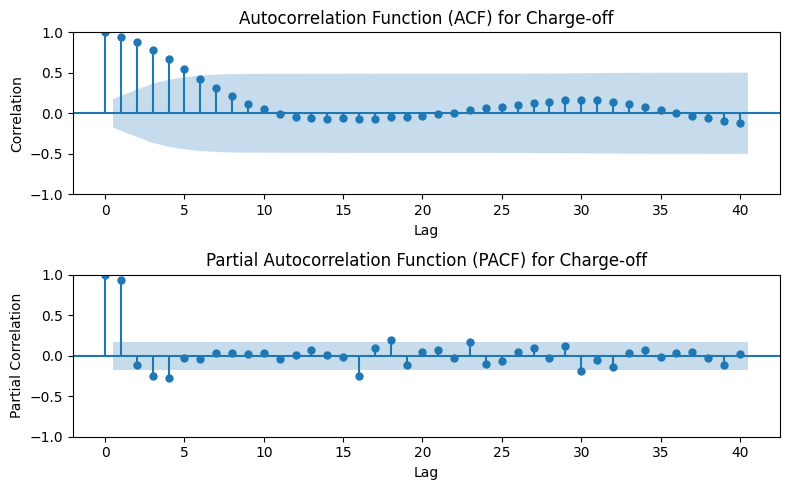

Charge-off's ACF 
 [ 1.          0.94204384  0.87464237  0.78257384  0.66450206  0.54637504
  0.42331819  0.30911296  0.20779285  0.11995576  0.05239781 -0.0030219
 -0.04120994 -0.05820459 -0.06476079 -0.06033516 -0.07055854 -0.06516455
 -0.04653304 -0.0446213  -0.02746573]
Charge-off's PACF 
 [ 1.00000000e+00  9.49702729e-01 -1.32101607e-01 -2.94362147e-01
 -3.26954737e-01 -1.74303531e-02 -2.62662587e-02  6.71999203e-02
  4.72863080e-02  2.48455589e-02  4.41688598e-02 -5.09491641e-02
 -2.32548545e-04  1.02262445e-01  2.29524696e-02 -2.32742997e-02
 -3.62463750e-01  1.32501006e-01  3.51010255e-01 -1.46677416e-01
  5.14400801e-03]


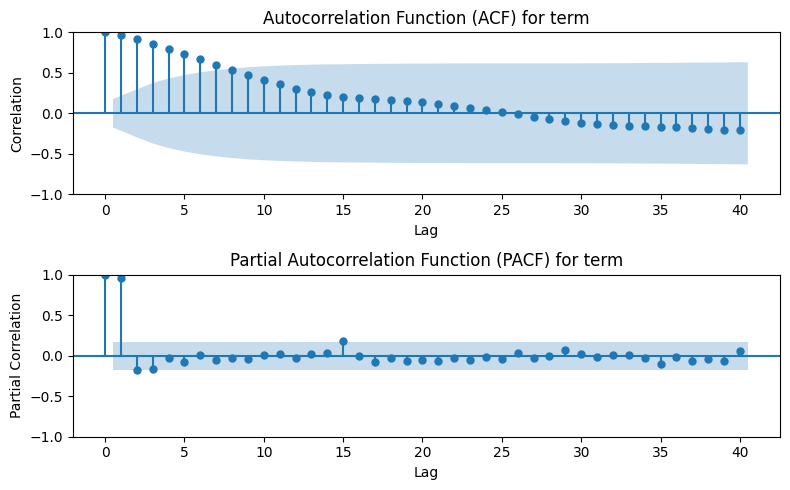

term's ACF 
 [1.         0.96336921 0.91586532 0.8570293  0.79542102 0.72959718
 0.66557473 0.60004754 0.53588605 0.47176045 0.41172083 0.35657661
 0.3046835  0.25900186 0.22066604 0.19992024 0.18608158 0.17436766
 0.16334814 0.1504836  0.13419918]
term's PACF 
 [ 1.          0.97113832 -0.21712283 -0.20642905 -0.02667011 -0.08357866
  0.01454364 -0.0708838  -0.0303874  -0.04691291  0.01803636  0.0334728
 -0.0397175   0.04302662  0.05625732  0.27218255 -0.01576271 -0.13837516
 -0.05015093 -0.09728213 -0.06801553]


In [14]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, acf, pacf

corc_1= corc_df.loc['1995':]
term_1= term_df.loc['1995':]
vars = {'Charge-off':corc_1,'term': term_1}


for name, df in vars.items():
    fig, (ax1,ax2) = plt.subplots(2,1,figsize=(8,5))

    plot_acf(df,lags=40, ax=ax1)
    ax1.set_title(f'Autocorrelation Function (ACF) for {name}')
    ax1.set_xlabel('Lag')
    ax1.set_ylabel('Correlation')

    plot_pacf(df,lags=40, ax=ax2)
    ax2.set_title(f'Partial Autocorrelation Function (PACF) for {name}')
    ax2.set_xlabel('Lag')
    ax2.set_ylabel('Partial Correlation')

    plt.tight_layout()
    plt.show()

    print(f"{name}'s ACF",'\n',acf(df))
    print(f"{name}'s PACF",'\n',pacf(df))



### Interpreting ACF / PACF

1) Charge-off

- We can see from the ACF that there is a high correlation with past values suggesting a prolonged AR 
- looking at our PACF, we see a large dip after lag 1 and then spikes at lag 3/4 suggesting seasonality, why? because its correlating with past data 3 lags ahead to be exact. We see these spikes again in lags 16 then 18 (a bit odd considering the time differences between them ~ might require more investigation to see why they are correlated.)


2) Term

- We see a much MUCH longer and slower correlational decay 
- PACF shows us when removing effects of past we still see spikes on lag 15 being a notable one. A bit suspicous maybe considering how far apart they are

Finding correlational value between variables vs. outcome

In [ ]:
print(len(drcc_df.loc['1995':]['value']),drcc_df.loc['1995':]['value'].tail(4))
print(len(corc_df.loc['1995':]['value']),corc_df.loc['1995':]['value'].tail(4))
print(len(term_df.loc['1995':'2025']['value']),term_df.loc['1995':]['value'].tail(4))


term_corr = term_df.loc['1995':]['value'].ffill().asfreq('QS').last()
drcc_corr = drcc_df.loc['1995':]['value'].asfreq('QS').last()



print(term_corr.isna().sum())



print('\n','The Correlation between Charge off rate and Delinquency rate is:',drcc_df.loc['1995':]['value'].corr(corc_df.loc['1995':]['value']))
print('\n','Correlation between delinquency and term length is:',term_corr.corr(drcc_corr))



#Figure out a way to match?

124 date
2025-01-01    3.06
2025-04-01    3.04
2025-07-01    2.98
2025-10-01    2.94
Name: value, dtype: float64
124 date
2025-01-01    4.43
2025-04-01    4.18
2025-07-01    4.18
2025-10-01    4.11
Name: value, dtype: float64
124 date
2025-05-01    21.16
2025-08-01    21.39
2025-11-01    20.97
2026-02-01    21.00
Name: value, dtype: float64


AttributeError: 'Series' object has no attribute 'last'

We have a time mismatch clearly, how should I split?
A couple of ideas:

- Align our data to yearly data, that way we'll have more aligned data points but probably not the best idea will be mising out on (4!!) predictions per year, since the data we're looking for, the delinquency rate, is calculated quarterly.

- try to match where we can? maybe align closes data to that data point ??

- let Pandas try to match the timelines as best it can

Let pandas merge

In [ ]:
df_multi = pd.concat([drcc_df,corc_df,term_df], axis =1 , join='outer')

C:\Users\Marwa\AppData\Local\Temp\ipykernel_9424\428149228.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_multi = pd.concat([drcc_df,corc_df,term_df], axis =1 , join='outer')


In [ ]:
# we chose 1995, since thats the earliest date that they all have data

df_multi = df_multi.loc["1995":]
print(len(df_multi),df_multi.head(10))


df_multinfiltered = df_multi.asfreq('QS').dropna()

print(len(df_multinfiltered))


#this had a much higher count since term had data starting at a much earlier date than the other two.

249             value  value  value
date                           
1995-01-01   3.48   2.96    NaN
1995-02-01    NaN    NaN  16.10
1995-04-01   3.67   3.29    NaN
1995-05-01    NaN    NaN  16.14
1995-07-01   3.86   3.66    NaN
1995-08-01    NaN    NaN  15.92
1995-10-01   3.96   3.93    NaN
1995-11-01    NaN    NaN  15.81
1996-01-01   4.04   4.23    NaN
1996-02-01    NaN    NaN  15.80
0


without term this time:
also Changing the name of Column from value to distinct name 

In [ ]:
drcc_df.rename(columns={'value': 'delinquency'}, inplace=True)
corc_df.rename(columns={'value': 'charge_off'}, inplace=True)

In [ ]:
df_multi1 = pd.concat([drcc_df,corc_df], axis =1 , join='outer')
df_multi1=df_multi1.asfreq('QS').dropna()
print(len(df_multi1),df_multi1.head(10))

140             delinquency  charge_off
date                               
1991-01-01         5.27        4.19
1991-04-01         5.44        4.63
1991-07-01         5.37        4.81
1991-10-01         5.31        4.63
1992-01-01         5.28        4.91
1992-04-01         5.06        4.84
1992-07-01         5.00        4.35
1992-10-01         4.69        4.50
1993-01-01         4.61        4.11
1993-04-01         4.43        3.95


C:\Users\Marwa\AppData\Local\Temp\ipykernel_9424\2420141979.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_multi1 = pd.concat([drcc_df,corc_df], axis =1 , join='outer')


## TERMCBCCALLNS — dropped

- Excluded due to time cycle mismatch -> quarterly cycle (QS-NOV vs QS-JAN) 
- data loss on merge (249 to 0 observations) after dropping Null



#### Next, we'll split into train val test

also introduce a feature engineered variable, 'anamoly flag'

In [ ]:
def traintestsplit(df):
    train = df.loc[:'2015']
    val = df.loc['2016':'2019']
    test = df.loc['2020':]

    return train,val ,test

def featureng(df):
    df_fe = df.copy()
    df_fe['anamoly_flag'] = ((df_fe['charge_off'] > 5) | 
                          (df_fe['charge_off'] < 2.0)).astype(int)
    return df_fe

df_multi1_fe = featureng(df_multi1)
# this only includes delinquency rates as well as charge off rates. Now we'll split
train_mv, val_mv, test_mv = traintestsplit(df_multi1_fe)





In [ ]:
print(len(train_mv[train_mv['anamoly_flag']==1])) # 35 points in time where we had 'anamoly' rates!

35


Plot the series
Run ADF + KPSS (stationarity test)
Difference if needed ---- We need to check for charge off rates as well...
Plot ACF/PACF

##### SARIMAX with Exogenous features

In [ ]:
def objective(trial):
    
    p_= trial.suggest_int("p", 0, 3)
    d_= trial.suggest_int("d", 0, 2)
    q_= trial.suggest_int("q", 0, 3)
    P_= trial.suggest_int("P", 0, 2)
    D_= trial.suggest_int("D", 0, 1)
    Q_= trial.suggest_int("Q", 0, 2)
    

    try:
        model = SARIMAX(train_mv['charge_off'],
                        exog=train_mv[['anamoly_flag','delinquency']],
                        order=(p_,d_,q_),
                        seasonal_order=(P_,D_,Q_,4),
                        enforce_stationarity=False,
                        enforce_invertibility=False)


        result = model.fit(disp=False,maxiter=200,method='powell')

        #forecasting over the val timeline

        y_pred = result.forecast(steps=len(val_mv),
                                 exog=val_mv[['anamoly_flag', 'delinquency']])
        y_pred.index = val_mv.index

        mae = (y_pred - val_mv['charge_off']).abs().mean()
        return mae

    except Exception:
        return 999


study = optuna.create_study(direction="minimize")
optuna.logging.set_verbosity(optuna.logging.WARNING)
study.optimize(objective, n_trials=50, timeout=600)

print("Best MAE:", f'{study.best_value:.4f}')
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Best MAE: 0.1778
Best params:
  p: 2
  d: 1
  q: 1
  P: 2
  D: 1
  Q: 1


Best MAE: 0.1778
Best params:
  p: 2
  d: 1
  q: 1
  P: 2
  D: 1
  Q: 1

One period differencing as before was best.